# 04 — Karak historical weather trends (2000–present)

**Purpose:** describe how modeled weather has varied over the long term at the configured Karak/Sabir Abad coordinate. This is intentionally separate from AQI training.

**Dataset:** `karak_weather_trend_open_meteo_daily_2000-01-01_to_<end>_<pull>.csv`. Daily summaries are used instead of a second sparse API pull: this preserves enough information to calculate annual means, extremes, precipitation totals, and trend slopes while keeping the file small and purpose-specific.

**Caveat:** these are Open-Meteo reanalysis/model values, not local weather-station measurements. A trend is descriptive evidence for this grid point, not a claim about every part of Karak.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '..').resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('Raw data directory:', RAW_DIR)


Project root: E:\10pearls-internship-2026\development
Raw data directory: E:\10pearls-internship-2026\development\data\raw


In [2]:
matches = sorted(RAW_DIR.glob('karak_weather_trend_open_meteo_daily_*.csv'))
if not matches:
    raise FileNotFoundError('No weather-trend file found. Run `python -m src.ingest` first.')
trend_path = matches[-1]
trend = pd.read_csv(trend_path, parse_dates=['time']).set_index('time').sort_index()
print('Trend file:', trend_path.name)
print('Rows:', len(trend), '| Columns:', len(trend.columns))
print('Range:', trend.index.min().date(), '->', trend.index.max().date())
print('Missing cells:', int(trend.isna().sum().sum()))


Trend file: karak_weather_trend_open_meteo_daily_2000-01-01_to_2026-07-31_20260731_181059.csv
Rows: 9709 | Columns: 9
Range: 2000-01-01 -> 2026-07-31
Missing cells: 0


### Finding from the loaded trend file

The printed filename, row count, date range, and missing-cell count are the provenance check. The file must begin in 2000 and must not be confused with the 2022-present AQI training file.


In [3]:
annual = trend.resample('YS').agg({
    'temperature_2m_mean': 'mean',
    'temperature_2m_max': 'mean',
    'temperature_2m_min': 'mean',
    'precipitation_sum': 'sum',
    'rain_sum': 'sum',
    'wind_speed_10m_mean': 'mean',
    'wind_gusts_10m_max': 'max',
    'relative_humidity_2m_mean': 'mean',
})
annual.index = annual.index.year
print('Annual rows:', len(annual))
print('Latest annual values:')
print(annual.tail(3).round(2).to_string())


Annual rows: 27
Latest annual values:
      temperature_2m_mean  temperature_2m_max  temperature_2m_min  precipitation_sum  rain_sum  wind_speed_10m_mean  wind_gusts_10m_max  relative_humidity_2m_mean
time                                                                                                                                                              
2024                21.82               26.75               17.44              891.0     890.6                 8.88                63.0                      54.21
2025                22.61               28.24               18.02              576.8     576.8                 7.41                69.1                      47.41
2026                22.29               27.50               17.80              368.5     368.2                 7.96                56.9                      51.42


In [4]:
def slope_per_decade(series):
    # 2026 is incomplete at the time of this pull. Exclude the current year
    # from regression, especially for annual totals such as precipitation.
    complete = series[series.index < pd.Timestamp.today().year].dropna()
    x = complete.index.to_numpy(dtype=float)
    y = complete.to_numpy(dtype=float)
    return np.polyfit(x, y, 1)[0] * 10

trend_rows = []
for column in ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'rain_sum', 'wind_speed_10m_mean', 'relative_humidity_2m_mean']:
    if column in annual:
        complete_annual = annual.loc[annual.index < pd.Timestamp.today().year]
        trend_rows.append({'variable': column, 'slope_per_decade': slope_per_decade(annual[column]), 'first_5y_mean': complete_annual[column].head(5).mean(), 'last_5y_mean': complete_annual[column].tail(5).mean()})
trend_table = pd.DataFrame(trend_rows).set_index('variable')
print('Trend estimates (linear slope per decade; complete years only):')
print(trend_table.round(3).to_string())
print('Current year shown as YTD in annual table but excluded from slopes and first/last complete-year means:', pd.Timestamp.today().year)
trend_table.to_csv(PROCESSED_DIR / 'karak_weather_trend_estimates_per_decade.csv')


Trend estimates (linear slope per decade; complete years only):
                           slope_per_decade  first_5y_mean  last_5y_mean
variable                                                                
temperature_2m_mean                   0.096         21.722        22.107
temperature_2m_max                    0.083         26.651        27.132
temperature_2m_min                    0.577         16.423        17.638
precipitation_sum                   -90.289        880.360       696.600
rain_sum                            -90.224        880.080       696.520
wind_speed_10m_mean                   1.318          6.474         8.991
relative_humidity_2m_mean            -1.839         56.441        52.003
Current year shown as YTD in annual table but excluded from slopes and first/last complete-year means: 2026


### Findings from the trend estimates

The `slope_per_decade` column is the quantitative answer to “what is happening.” Compare it with the first-versus-last five-year means, because a linear slope can hide breaks, missing years, or non-linear variability. The notebook deliberately reports temperature, precipitation, wind, humidity, and rain separately rather than collapsing weather into one unsupported conclusion.


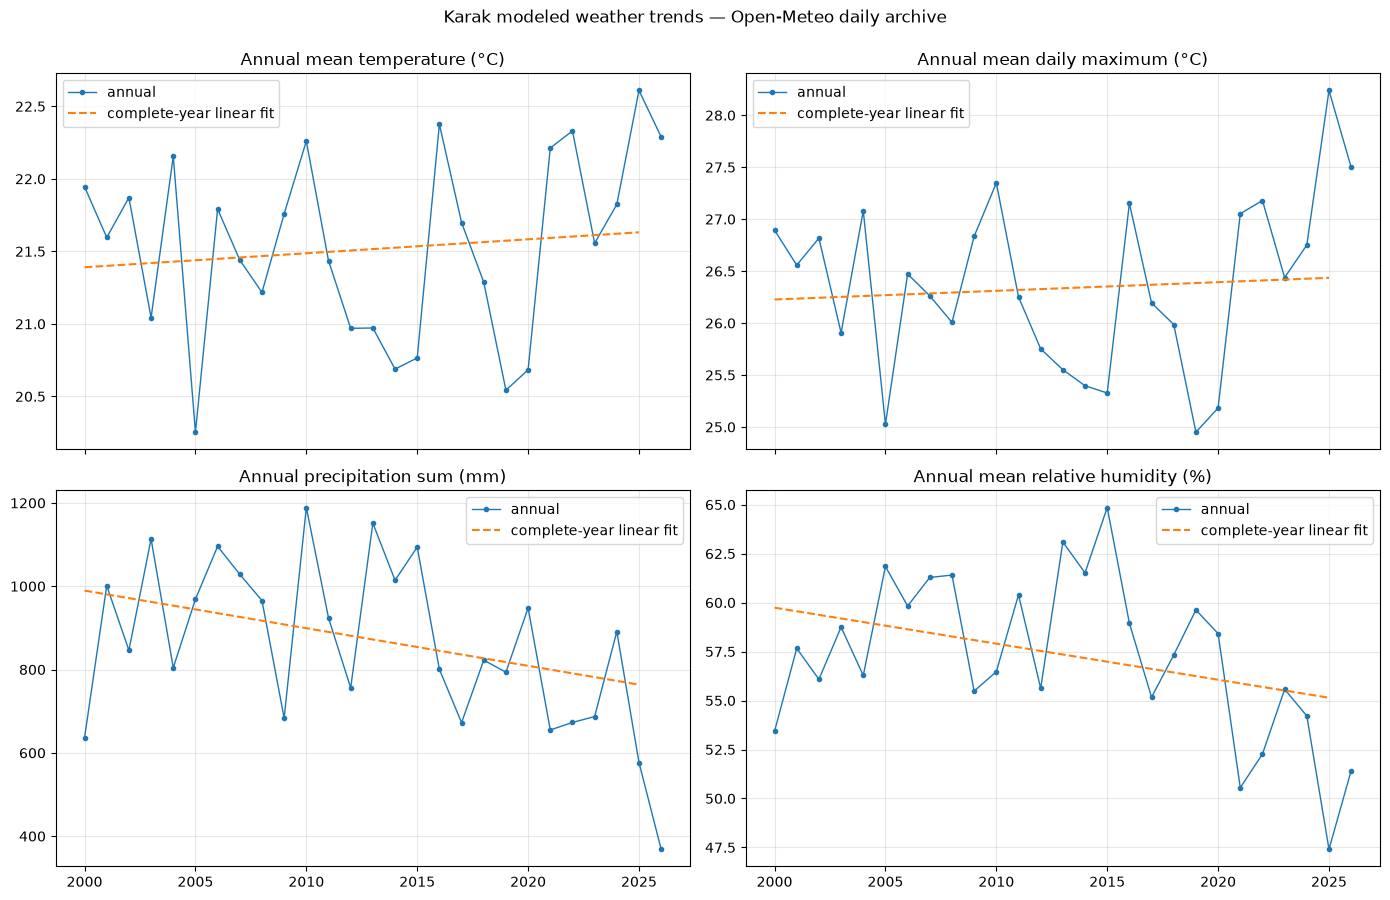

Saved trend figure: E:\10pearls-internship-2026\development\data\processed\karak_weather_trends_2000_present.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
plots = [
    ('temperature_2m_mean', 'Annual mean temperature (°C)'),
    ('temperature_2m_max', 'Annual mean daily maximum (°C)'),
    ('precipitation_sum', 'Annual precipitation sum (mm)'),
    ('relative_humidity_2m_mean', 'Annual mean relative humidity (%)'),
]
for ax, (column, title) in zip(axes.flat, plots):
    if column in annual:
        ax.plot(annual.index, annual[column], marker='.', linewidth=1, label='annual')
        clean = annual.loc[annual.index < pd.Timestamp.today().year, column].dropna()
        if len(clean) > 1:
            fit = np.polyval(np.polyfit(clean.index, clean.to_numpy(), 1), clean.index)
            ax.plot(clean.index, fit, '--', label='complete-year linear fit')
        ax.set_title(title)
        ax.grid(alpha=.3)
        ax.legend()
fig.suptitle('Karak modeled weather trends — Open-Meteo daily archive', y=.995)
fig.tight_layout()
fig.savefig(PROCESSED_DIR / 'karak_weather_trends_2000_present.png', dpi=140)
plt.show()
print('Saved trend figure:', PROCESSED_DIR / 'karak_weather_trends_2000_present.png')


## 04 decision and interpretation

Use the generated trend table and figure to discuss the Karak weather history. Do not use this file as an AQI target, and do not merge it into the 2022-present hourly AQI dataset unless the sampling/aggregation decision is explicitly documented.
